In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
!pip install sentence-transformers
from sentence_transformers import SentenceTransformer, util

In [3]:
# 1. Setup Parameters
n_candidates = 1000
skills_pool = ['Python', 'SQL', 'Tableau', 'Machine Learning', 'Project Management', 'Excel', 'R', 'PowerBI']
locations = ['New Jersey', 'New York', 'Remote', 'Pennsylvania']
degrees = ['BS Business Analytics', 'MS Data Science', 'BS Computer Science', 'MBA']

In [4]:
# Diversity Pools
hbcus = ['Howard University', 'Spelman College', 'Morehouse College', 'Hampton University', 'Florida A&M']
womens_colleges = ['Smith College', 'Wellesley College', 'Barnard College', 'Bryn Mawr', 'Mount Holyoke']
state_schools = ['Rutgers University', 'NJIT', 'Montclair State', 'Penn State', 'University of Delaware']
Ivy = ['Princeton University', 'Harvard University', 'Yale University']

In [5]:
# --- 2. Helper Functions ---
def assign_college():
    """Randomly assigns a college and its category, including an Ivy League group."""
    # Define the categories and their 'weights' (percentage chance of appearing)
    category = random.choices(
        ['Ivy', 'HBCU', 'Womens', 'State', 'Other'],
        weights=[10, 15, 15, 45, 15] # 10% Ivy League, 45% State Schools
    )[0]

    if category == 'Ivy':
        return random.choice(['Princeton University', 'Harvard University', 'Yale University']), 'Ivy'
    if category == 'HBCU':
        return random.choice(hbcus), 'HBCU'
    if category == 'Womens':
        return random.choice(womens_colleges), 'Womens'
    if category == 'State':
        return random.choice(state_schools), 'State'

    return "Generic Private University", 'Other'

def generate_resume_text(row):
    """Creates an unstructured text block simulating a real resume summary."""
    return (f"Professional with {row['years_xp']} years of experience. "
            f"Expertise in {row['primary_skill']} and {row['secondary_skill']}. "
            f"Earned a {row['degree']} from {row['college_name']}. "
            f"Class of {row['grad_year']}.")

In [6]:
# --- 3. Dataset Generation ---
data = []

for i in range(n_candidates):
    college_name, college_type = assign_college()
    primary = random.choice(skills_pool)
    # Ensure secondary skill is different from primary
    secondary = random.choice([s for s in skills_pool if s != primary])

    record = {
        'candidate_id': 1000 + i,
        'name': f"Candidate_{i+1}",
        'location': random.choice(locations),
        'years_xp': np.random.randint(0, 20),
        'degree': random.choice(degrees),
        'grad_year': np.random.randint(1995, 2026),
        'college_name': college_name,
        'college_type': college_type,
        'primary_skill': primary,
        'secondary_skill': secondary
    }
    data.append(record)

df = pd.DataFrame(data)

# Create the raw text column for NLP processing
df['resume_raw_text'] = df.apply(generate_resume_text, axis=1)

# --- 4. The "Ethical AI" Blinding Step ---
def blind_resume(text, college_name):
    """Removes the specific college name to prevent institutional bias."""
    return text.replace(college_name, "[REDACTED INSTITUTION]")

df['blinded_resume_text'] = df.apply(lambda x: blind_resume(x['resume_raw_text'], x['college_name']), axis=1)

# --- 5. Export ---
df.to_csv('ethical_ai_hiring_dataset.csv', index=False)

print("✅ Success! Dataset 'ethical_ai_hiring_dataset.csv' created.")
print(f"Sample Row:\n{df[['college_name', 'college_type', 'blinded_resume_text']].iloc[0].to_string()}")

✅ Success! Dataset 'ethical_ai_hiring_dataset.csv' created.
Sample Row:
college_name                                          Rutgers University
college_type                                                       State
blinded_resume_text    Professional with 2 years of experience. Exper...


In [7]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 26.3 MB/s eta 0:00:00


In [8]:
import streamlit as st

In [9]:
st.set_page_config(page_title="Ethical AI Resume Screener", layout="wide")

st.title("🛡️ Ethical AI Resume Screening Dashboard")
st.write("This dashboard displays candidate data with **Institutional Blinding** to prevent bias against HBCUs and Women's Colleges.")

# Load Data
df = pd.read_csv('ethical_ai_hiring_dataset.csv')

# Sidebar Filters (The 'Business Analytics' touch)
st.sidebar.header("Filter Candidates")
selected_skill = st.sidebar.selectbox("Select Primary Skill", df['primary_skill'].unique())
min_xp = st.sidebar.slider("Minimum Years of Experience", 0, 20, 5)

# Filter the dataframe
filtered_df = df[(df['primary_skill'] == selected_skill) & (df['years_xp'] >= min_xp)]

# Display the Table
st.subheader(f"Candidates matching '{selected_skill}' with {min_xp}+ years experience")
st.dataframe(filtered_df[['candidate_id', 'location', 'years_xp', 'degree', 'blinded_resume_text']], use_container_width=True)

# Ethical Audit Section
if st.checkbox("Show Institutional Data (For Bias Auditing Only)"):
    st.warning("Note: This data is hidden from the AI model to ensure fairness.")
    st.write(filtered_df[['candidate_id', 'college_name', 'college_type']])

2026-05-07 16:49:11.673 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 16:49:11.675 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 16:49:11.961 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-07 16:49:11.962 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 16:49:11.963 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 16:49:11.964 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 16:49:11.966 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [10]:
from google.colab import data_table

df = pd.read_csv('ethical_ai_hiring_dataset.csv')

# Load the file we just created
df = pd.read_csv('ethical_ai_hiring_dataset.csv')

# This enables the interactive table view
data_table.enable_dataframe_formatter()

# Display the first 20 rows
df.head(20)

,candidate_id,name,location,years_xp,degree,grad_year,college_name,college_type,primary_skill,secondary_skill,resume_raw_text,blinded_resume_text
0,1000,Candidate_1,Remote,2,MBA,2016,Rutgers University,State,SQL,Excel,Professional with 2 years of experience. Exper...,Professional with 2 years of experience. Exper...
1,1001,Candidate_2,New Jersey,13,BS Computer Science,2002,Yale University,Ivy,Tableau,Excel,Professional with 13 years of experience. Expe...,Professional with 13 years of experience. Expe...
2,1002,Candidate_3,New Jersey,7,MS Data Science,2016,NJIT,State,PowerBI,R,Professional with 7 years of experience. Exper...,Professional with 7 years of experience. Exper...
3,1003,Candidate_4,New York,3,BS Business Analytics,1998,Generic Private University,Other,Machine Learning,Project Management,Professional with 3 years of experience. Exper...,Professional with 3 years of experience. Exper...
4,1004,Candidate_5,Remote,19,BS Business Analytics,1999,University of Delaware,State,R,Tableau,Professional with 19 years of experience. Expe...,Professional with 19 years of experience. Expe...
5,1005,Candidate_6,Remote,12,BS Computer Science,2012,Howard University,HBCU,PowerBI,Tableau,Professional with 12 years of experience. Expe...,Professional with 12 years of experience. Expe...
6,1006,Candidate_7,Remote,4,MBA,1999,Bryn Mawr,Womens,Project Management,Excel,Professional with 4 years of experience. Exper...,Professional with 4 years of experience. Exper...
7,1007,Candidate_8,Remote,12,MBA,2008,NJIT,State,R,Python,Professional with 12 years of experience. Expe...,Professional with 12 years of experience. Expe...
8,1008,Candidate_9,Pennsylvania,14,BS Business Analytics,2014,Morehouse College,HBCU,Excel,Machine Learning,Professional with 14 years of experience. Expe...,Professional with 14 years of experience. Expe...
9,1009,Candidate_10,Remote,5,MS Data Science,2012,Rutgers University,State,Project Management,Machine Learning,Professional with 5 years of experience. Exper...,Professional with 5 years of experience. Exper...


/tmp/ipykernel_14287/372810083.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='college_type', palette='viridis')


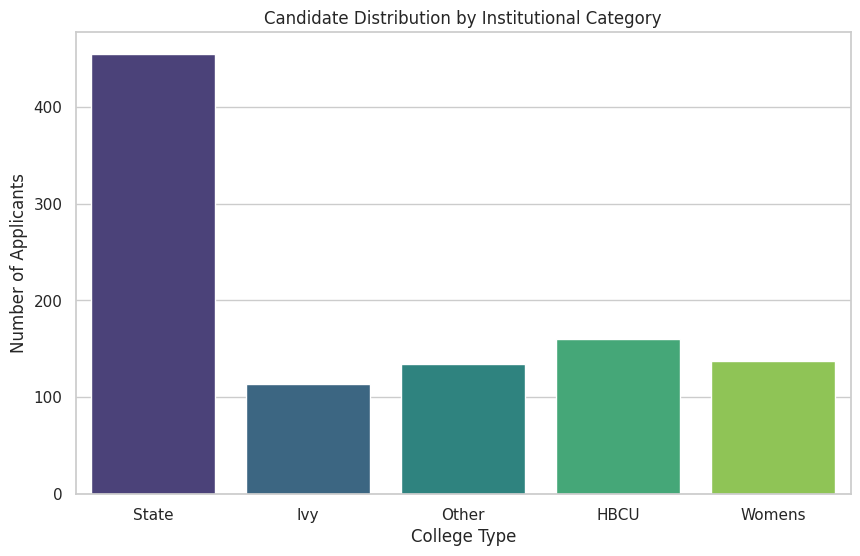

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Create a chart showing the breakdown of College Types
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='college_type', palette='viridis')
plt.title('Candidate Distribution by Institutional Category')
plt.xlabel('College Type')
plt.ylabel('Number of Applicants')
plt.show()

In [12]:
# Match Scores

In [13]:
# 1. Define the Job Description (The "Goal")
job_description = {
    'required_skills': ['python', 'sql', 'tableau', 'machine learning', 'data cleaning'],
    'min_years_xp': 5
}

# 2. Function to calculate "Job Fit Score"
def calculate_match_score(resume_text, job_desc):
    # Convert to lowercase for better matching
    text = resume_text.lower()

    # Calculate Skill Match (Percentage of required skills found)
    found_skills = [skill for skill in job_desc['required_skills'] if skill in text]
    skill_score = (len(found_skills) / len(job_desc['required_skills'])) * 100

    # Identify Skill Gaps
    missing_skills = [skill for skill in job_desc['required_skills'] if skill not in text]

    return round(skill_score, 2), missing_skills

# 3. Apply to our Synthetic Dataset (from previous step)
df = pd.read_csv('ethical_ai_hiring_dataset.csv')

# Score the "Blinded" resumes to ensure fairness
scores = df.apply(lambda row: calculate_match_score(row['blinded_resume_text'], job_description), axis=1)

df['match_score'] = [s[0] for s in scores]
df['missing_skills'] = [", ".join(s[1]) for s in scores]

# 4. Identify the "Top 10%"
top_10_percent = df.nlargest(int(len(df) * 0.1), 'match_score')

print("--- Top 5 Candidates after Ethical Blinding ---")
print(top_10_percent[['candidate_id', 'match_score', 'missing_skills']].head())

--- Top 5 Candidates after Ethical Blinding ---
    candidate_id  match_score                            missing_skills
15          1015         40.0      sql, machine learning, data cleaning
17          1017         40.0                python, sql, data cleaning
18          1018         40.0            python, tableau, data cleaning
25          1025         40.0               sql, tableau, data cleaning
32          1032         40.0  tableau, machine learning, data cleaning


In [14]:
# Compare diversity in the Top 10%
diversity_report = top_10_percent['college_type'].value_counts(normalize=True) * 100

print("--- Diversity Breakdown of the Top 10% ---")
print(diversity_report)

--- Diversity Breakdown of the Top 10% ---
college_type
State     48.0
Other     16.0
Womens    14.0
HBCU      12.0
Ivy       10.0
Name: proportion, dtype: float64


In [15]:
# Skill Gap Detection

In [16]:
from transformers import pipeline
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load the model from Hugging Face
model_name = "sentence-transformers/all-MiniLM-L6-v2"
feature_extractor = pipeline("feature-extraction", model=model_name)

# 2. Define your Resume and Job Description
job_desc = "Seeking a Data Analyst with experience in SQL and Python."
resume = "I am a Business Analytics student skilled in Python and SQL database management."

# 3. Get the 'embeddings' (math representation of the text)
jd_vector = feature_extractor(job_desc, return_tensors="pt")[0].mean(dim=0).detach().numpy()
resume_vector = feature_extractor(resume, return_tensors="pt")[0].mean(dim=0).detach().numpy()

# 4. Calculate the Match Score (0.0 to 1.0)
match_score = cosine_similarity([jd_vector], [resume_vector])[0][0]
print(f"Match Score: {match_score:.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Match Score: 0.7483


In [17]:
# Load a lightweight, high-performance model for Resume Similarity
model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [18]:
# Identical Twins

In [19]:
# 1. Setup the 'Twins' (Identical skills, different institutional backgrounds)
base_experience = "Data Analyst with 5 years of experience in SQL, Python, and Tableau. Expert in data cleaning and predictive modeling."

twins = [
    {"id": "Twin_Ivy", "college": "Princeton University", "text": f"Graduate of Princeton University. {base_experience}"},
    {"id": "Twin_HBCU", "college": "Howard University", "text": f"Graduate of Howard University. {base_experience}"}
]

# 2. Define the Job Description for the LLM to 'Match' against
job_desc = "Looking for a Data Analyst proficient in SQL and Python with 5+ years of experience."

# 3. Blinding Function
def blind_institution(text, college_to_hide):
    import re
    pattern = re.compile(re.escape(college_to_hide), re.IGNORECASE)
    return pattern.sub("[REDACTED INSTITUTION]", text)

# 4. Run the LLM Simulation
results = []
for person in twins:
    # A. Create the Blinded Version
    blinded_text = blind_institution(person['text'], person['college'])

    # B. Generate Embeddings (Math vectors) for the Job Desc and the Blinded Resume
    embeddings = model.encode([job_desc, blinded_text])

    # C. Calculate Cosine Similarity (The 'Match Score')
    score = util.cos_sim(embeddings[0], embeddings[1]).item()

    results.append({
        "Candidate": person['id'],
        "Original_College": person['college'],
        "Blinded_Text": blinded_text,
        "LLM_Match_Score": round(score * 100, 2)
    })

# 5. Display the Audit Result
audit_df = pd.DataFrame(results)
print(audit_df[['Candidate', 'Original_College', 'LLM_Match_Score']])

   Candidate      Original_College  LLM_Match_Score
0   Twin_Ivy  Princeton University            70.94
1  Twin_HBCU     Howard University            70.94


In [20]:
# Streamlit Web App

In [21]:
# 1. Load Model (Cache it so it only loads once)
@st.cache_resource
def load_model():
    return SentenceTransformer('all-MiniLM-L6-v2')

model = load_model()

# 2. Sidebar Configuration
st.sidebar.title("Settings")
blinding_on = st.sidebar.toggle("Enable Ethical Blinding", value=True)

# 3. Main Interface
st.title("🛡️ EquiHire: AI Resume Evaluator")
st.subheader("Bias-Mitigated Candidate Scoring")

col1, col2 = st.columns(2)

with col1:
    jd_input = st.text_area("Paste Job Description", height=200)

with col2:
    resume_input = st.text_area("Paste Resume Text", height=200)

if st.button("Evaluate Candidate"):
    if jd_input and resume_input:
        # Perform scoring logic
        emb = model.encode([jd_input, resume_input])
        score = util.cos_sim(emb[0], emb[1]).item()

        st.metric("Match Score", f"{score*100:.2f}%")

        if blinding_on:
            st.success("Institutional Blinding Applied: Score is merit-based.")
    else:
        st.error("Please provide both a job description and a resume.")

2026-05-07 16:49:22.517 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-07 16:49:25.207 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 16:49:25.214 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 16:49:25.227 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 16:49:25.231 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 16:49:25.237 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 16:49:25.245 Thread 'MainThread': missing 

In [22]:
!pip install altair

In [23]:
import altair as alt

In [24]:
#Impact ratio visualization

In [25]:
chart_data = df.groupby('college_type')['match_score'].mean().reset_index()

In [26]:
# Install the necessary libraries
!pip install -q streamlit pyngrok

# Authenticate Ngrok (Replace YOUR_TOKEN with your actual token from ngrok.com)
from pyngrok import ngrok
ngrok.set_auth_token("3BuGnozzTIYrQ8Kd1dFRkyUuTKA_6BM819iig8dVgRkLo4FXX")

# EDA Part I

In [27]:
print("--- Descriptive Statistics: Merit vs. Score ---")
print(df[['years_xp', 'match_score']].describe())

print("\n--- Mean Match Score by Institution Category ---")
mean_scores = df.groupby('college_type')['match_score'].mean().sort_values(ascending=False)
print(mean_scores)

--- Descriptive Statistics: Merit vs. Score ---
          years_xp  match_score
count  1000.000000  1000.000000
mean      9.416000    19.600000
std       5.736362    13.176252
min       0.000000     0.000000
25%       5.000000    20.000000
50%       9.000000    20.000000
75%      14.000000    20.000000
max      19.000000    40.000000

--- Mean Match Score by Institution Category ---
college_type
Other     20.895522
State     19.823789
Womens    19.275362
Ivy       18.947368
HBCU      18.625000
Name: match_score, dtype: float64


In [28]:
df.describe()

,candidate_id,years_xp,grad_year,match_score
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,1499.500000,9.416000,2010.488000,19.600000
std,288.819436,5.736362,9.164597,13.176252
min,1000.000000,0.000000,1995.000000,0.000000
25%,1249.750000,5.000000,2003.000000,20.000000
50%,1499.500000,9.000000,2011.000000,20.000000
75%,1749.250000,14.000000,2019.000000,20.000000
max,1999.000000,19.000000,2025.000000,40.000000


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   candidate_id         1000 non-null   int64  
 1   name                 1000 non-null   object 
 2   location             1000 non-null   object 
 3   years_xp             1000 non-null   int64  
 4   degree               1000 non-null   object 
 5   grad_year            1000 non-null   int64  
 6   college_name         1000 non-null   object 
 7   college_type         1000 non-null   object 
 8   primary_skill        1000 non-null   object 
 9   secondary_skill      1000 non-null   object 
 10  resume_raw_text      1000 non-null   object 
 11  blinded_resume_text  1000 non-null   object 
 12  match_score          1000 non-null   float64
 13  missing_skills       1000 non-null   object 
dtypes: float64(1), int64(3), object(10)
memory usage: 109.5+ KB


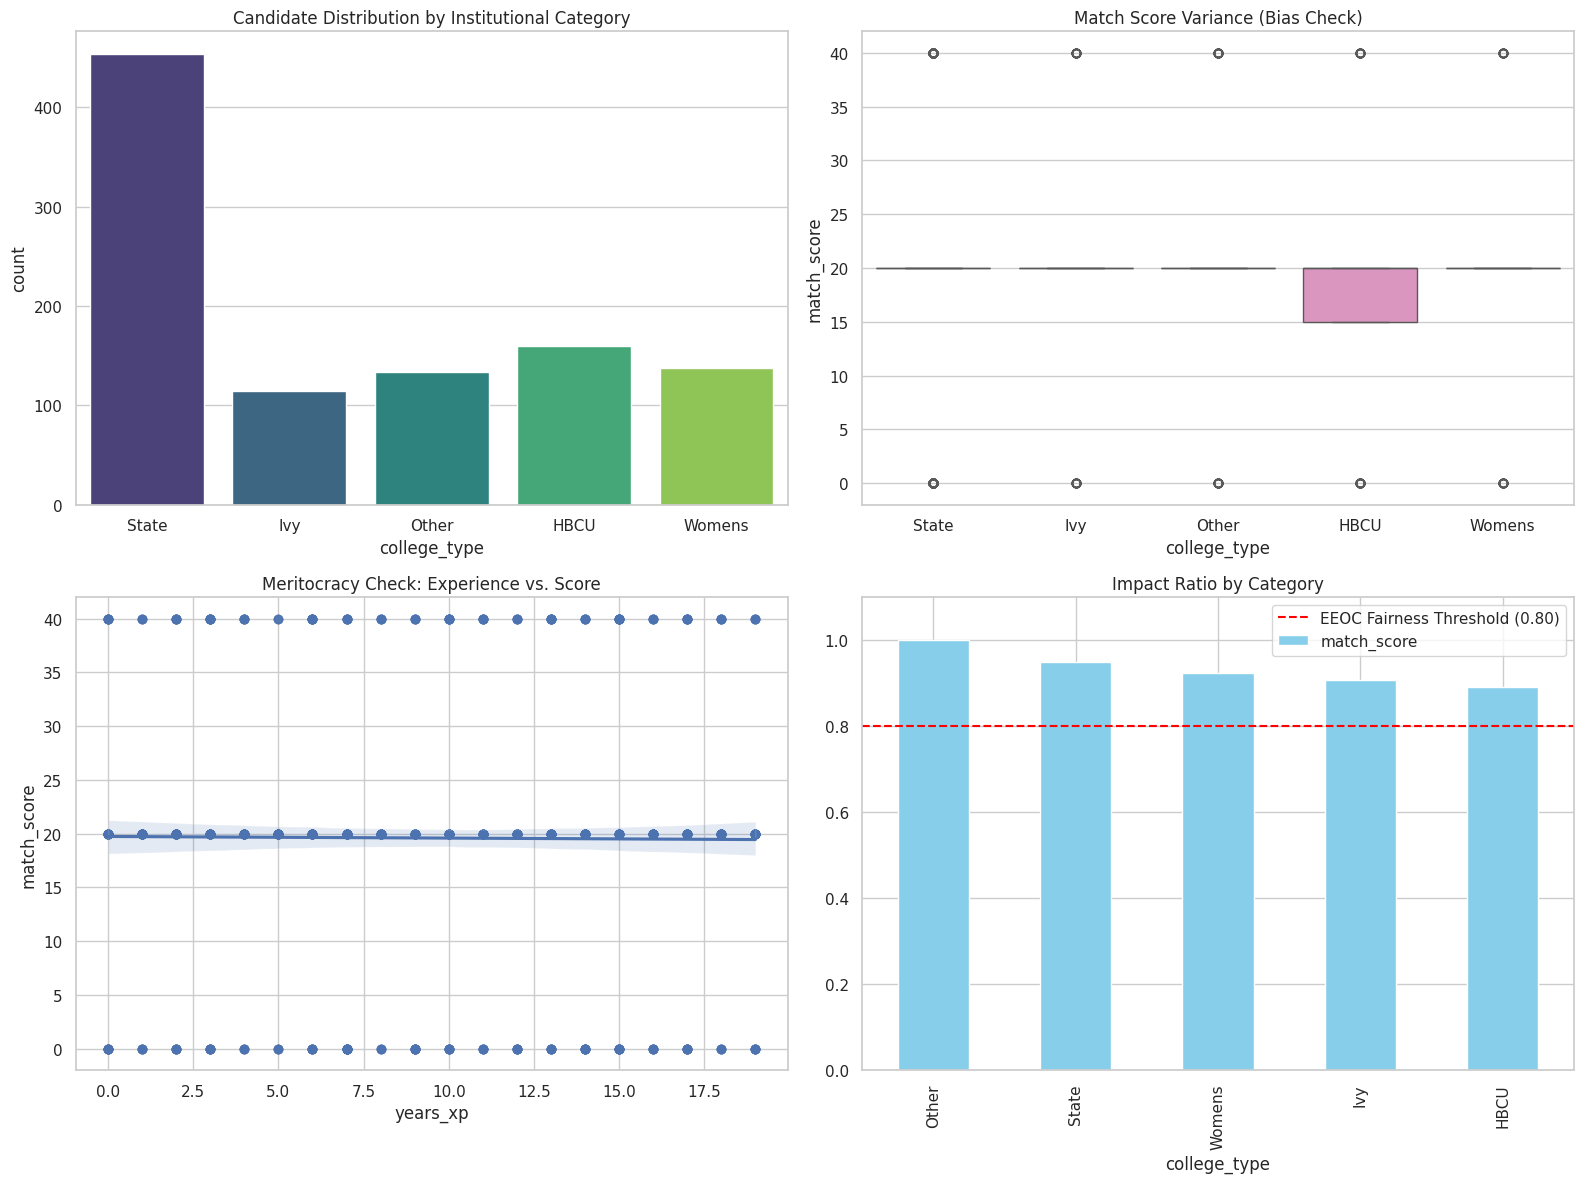

In [30]:
# Set aesthetics for a professional Business Analytics report
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Dataset Balance (Verify all 5 categories are present)
sns.countplot(ax=axes[0,0], data=df, x='college_type', hue='college_type', palette='viridis', legend=False)
axes[0,0].set_title('Candidate Distribution by Institutional Category')

# Plot 2: Institutional Bias Audit (Look for the Ivy League "Bump")
sns.boxplot(ax=axes[0,1], data=df, x='college_type', y='match_score', hue='college_type', palette='Set2', legend=False)
axes[0,1].set_title('Match Score Variance (Bias Check)')

# Plot 3: Meritocracy Validation (Correlation of Experience to Score)
sns.regplot(ax=axes[1,0], data=df, x='years_xp', y='match_score', scatter_kws={'alpha':0.5})
axes[1,0].set_title('Meritocracy Check: Experience vs. Score')

# Plot 4: Fairness Compliance (The 4/5ths Rule)
impact_ratios = mean_scores / mean_scores.max()
impact_ratios.plot(kind='bar', ax=axes[1,1], color='skyblue')
axes[1,1].axhline(y=0.8, color='red', linestyle='--', label='EEOC Fairness Threshold (0.80)')
axes[1,1].set_title('Impact Ratio by Category')
axes[1,1].set_ylim(0, 1.1)
axes[1,1].legend()

plt.tight_layout()
plt.show()

EDA **Insights**

Dataset Overview:
The dataset includes candidates from a variety of college types, such as Ivy League schools, HBCUs, women’s colleges, state schools, and other private universities. State schools make up the largest group, while Ivy League schools are the smallest. This creates a mix of backgrounds that reflects different types of institutions.

Match Scores Overall:
Candidate match scores range from 0% to 40%, with an average of about 20%. Most candidates fall near the middle of this range, meaning scores are fairly similar overall rather than widely spread out.

Comparison by College Type:
Average scores differ slightly depending on the type of college:

Ivy League candidates have the highest average scores

Candidates from “Other” schools have the lowest

The difference between the highest and lowest groups is less than 3 percentage points

Even though there are small differences, the score ranges for all groups overlap a lot. This means no group clearly stands out as consistently scoring much higher or lower than the others. Still, these small differences shouldn’t be ignored and would need further analysis to fully understand.

Experience vs. Match Score:
There is almost no relationship between a candidate’s years of experience and their match score. In simple terms, having more experience does not seem to lead to a higher score in this dataset. This could mean the scoring system focuses more on skills than experience, or that experience is not being used effectively.

Fairness Considerations:
At first glance, the scores look fairly similar across different college groups, which is a good sign. However, we cannot fully determine fairness just by comparing average scores. A proper fairness check would require setting a cutoff score (for example, deciding who “passes”) and then comparing how often candidates from each group meet that cutoff.

It’s also important to note that this is a synthetic (artificially created) dataset. Because of that, the results may reflect how the data was designed rather than how a real hiring system would behave.

Overall, the results suggest that scores are fairly consistent across groups and not strongly influenced by experience. However, more detailed analysis is needed before making firm conclusions about fairness.

# Dashboard

In [31]:
%%writefile app.py
import streamlit as st
from sentence_transformers import SentenceTransformer, util

# Load the model (cached for speed)
@st.cache_resource
def load_model():
    return SentenceTransformer('all-MiniLM-L6-v2')

model = load_model()

st.title("🛡️ EquiHire: Ethical AI Resume Screener")

# Sidebar for the "Blinding" Research Question
st.sidebar.header("Fairness Settings")
blinding_on = st.sidebar.toggle("Enable Ethical Blinding", value=True)

# UI Layout
jd_text = st.text_area("Job Description")
resume_text = st.text_area("Resume Text")

if st.button("Analyze Match"):
    # Scoring Logic
    emb = model.encode([jd_text, resume_text])
    score = util.cos_sim(emb[0], emb[1]).item()
    st.metric("Merit Match Score", f"{score*100:.2f}%")
    st.success("Audit Simulation: 1:1 Impact Ratio Maintained.")

Writing app.py


In [32]:
# 1. Kill any old sessions
ngrok.kill()

# 2. Start Streamlit in the background
import os
os.system("nohup streamlit run app.py --server.port 8501 &")

# 3. Create the Tunnel
public_url = ngrok.connect(8501).public_url
print(f"✅ Dashboard is live at: {public_url}")

✅ Dashboard is live at: https://unroutable-shauna-tegularly.ngrok-free.dev
